# WebArena-Verified Hard EDA

Dieses Notebook analysiert den WebArena-Verified Hard Subset als Datensatz. Es fuehrt keine Agent-Runs aus. Ziel ist eine Data-Science-Sicht auf Haeufigkeiten, Sites, Task-Typen, Intent-Laengen, Evaluator-Arten und Beispielzeilen pro Kategorie.

In [23]:
from pathlib import Path
import json
import sys
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

OFFICIAL_REPO = ROOT / 'external' / 'webarena-verified'
DATASET_PATH = OFFICIAL_REPO / 'assets/dataset/webarena-verified.json'
HARD_SUBSET_PATH = OFFICIAL_REPO / 'assets/dataset/subsets/webarena-verified-hard.json'

pd.set_option('display.max_colwidth', 180)
pd.set_option('display.max_columns', 120)
plt.style.use('seaborn-v0_8-whitegrid')

SCRIPTS_DIR = ROOT / 'scripts'
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from hk_agent.task_loader import capability_tier, infer_task_capability

DATASET_PATH, HARD_SUBSET_PATH


(PosixPath('/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/assets/dataset/webarena-verified.json'),
 PosixPath('/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/assets/dataset/subsets/webarena-verified-hard.json'))

## Load Dataset

In [24]:
dataset = json.loads(DATASET_PATH.read_text())
hard_info = json.loads(HARD_SUBSET_PATH.read_text())
hard_ids = set(int(task_id) for task_id in hard_info['task_ids'])

def task_type(task):
    values = []
    for evaluator in task.get('eval', []):
        expected = evaluator.get('expected', {})
        if expected.get('task_type'):
            values.append(str(expected['task_type']).upper())
    if values:
        return '+'.join(sorted(set(values)))
    if task.get('eval'):
        return 'NETWORK_OR_UI'
    return 'UNKNOWN'

def evaluator_names(task):
    names = [str(evaluator.get('evaluator', 'UNKNOWN')) for evaluator in task.get('eval', [])]
    return '+'.join(names) if names else 'UNKNOWN'

def intent_bucket(length):
    if length < 60:
        return 'short'
    if length < 140:
        return 'medium'
    return 'long'

def gym_id(task):
    return f"browsergym/webarena_verified.{task['intent_template_id']}.{task['task_id']}.{task['revision']}"

rows = []
for task in dataset:
    sites = [str(site) for site in task.get('sites', [])]
    primary_site = sites[0] if sites else 'unknown'
    capability = infer_task_capability(task, primary_site)
    intent = task.get('intent', '')
    rows.append({
        'task_id': int(task['task_id']),
        'hard_subset': int(task['task_id']) in hard_ids,
        'intent_template_id': task.get('intent_template_id'),
        'revision': task.get('revision'),
        'sites': ','.join(sites),
        'primary_site': primary_site,
        'num_sites': len(sites),
        'single_site': len(sites) == 1,
        'contains_map': 'map' in sites,
        'contains_wikipedia': 'wikipedia' in sites,
        'task_type': task_type(task),
        'task_capability': capability,
        'capability_tier': capability_tier(capability),
        'evaluator_names': evaluator_names(task),
        'num_evaluators': len(task.get('eval', [])),
        'intent_length': len(intent),
        'intent_word_count': len(intent.split()),
        'intent_bucket': intent_bucket(len(intent)),
        'gym_id': gym_id(task),
        'intent': intent,
    })

all_df = pd.DataFrame(rows)
hard_df = all_df[all_df['hard_subset']].copy()

print('All WebArena-Verified tasks:', len(all_df))
print('Hard subset tasks:', len(hard_df))
display(hard_df.head())


All WebArena-Verified tasks: 812
Hard subset tasks: 258


,task_id,hard_subset,intent_template_id,revision,sites,num_sites,single_site,contains_map,contains_wikipedia,task_type,evaluator_names,num_evaluators,intent_length,intent_word_count,intent_bucket,gym_id,intent
11,11,True,288,2,shopping_admin,1,True,False,False,RETRIEVE,AgentResponseEvaluator,1,95,16,medium,browsergym/webarena_verified.288.11.2,"Get the total number of reviews that our store received so far that mention term ""disappointed"""
15,15,True,288,2,shopping_admin,1,True,False,False,RETRIEVE,AgentResponseEvaluator,1,87,16,medium,browsergym/webarena_verified.288.15.2,"Get the total number of reviews that our store received so far that mention term ""best"""
21,21,True,222,2,shopping,1,True,False,False,RETRIEVE,AgentResponseEvaluator,1,95,17,medium,browsergym/webarena_verified.222.21.2,Get name(s) of reviewer(s) who mention ear cups being small for the product on the current page
25,25,True,222,2,shopping,1,True,False,False,RETRIEVE,AgentResponseEvaluator,1,132,24,medium,browsergym/webarena_verified.222.25.2,Get name(s) of reviewer(s) who mention print quality explicitly with a rating of 3 or less stars for the product on the current page
28,28,True,33,2,reddit,1,True,False,False,RETRIEVE,AgentResponseEvaluator,1,267,47,long,browsergym/webarena_verified.33.28.2,"In the Worcester forum, get the username and post title of the most recent post, and count the number of comments on that post that are not from the author and have more downvo..."


## Overall Counts

,metric,value
0,all_tasks,812
1,hard_tasks,258
2,hard_single_site,210
3,hard_multi_site,48
4,hard_contains_map,19
5,hard_contains_wikipedia,23


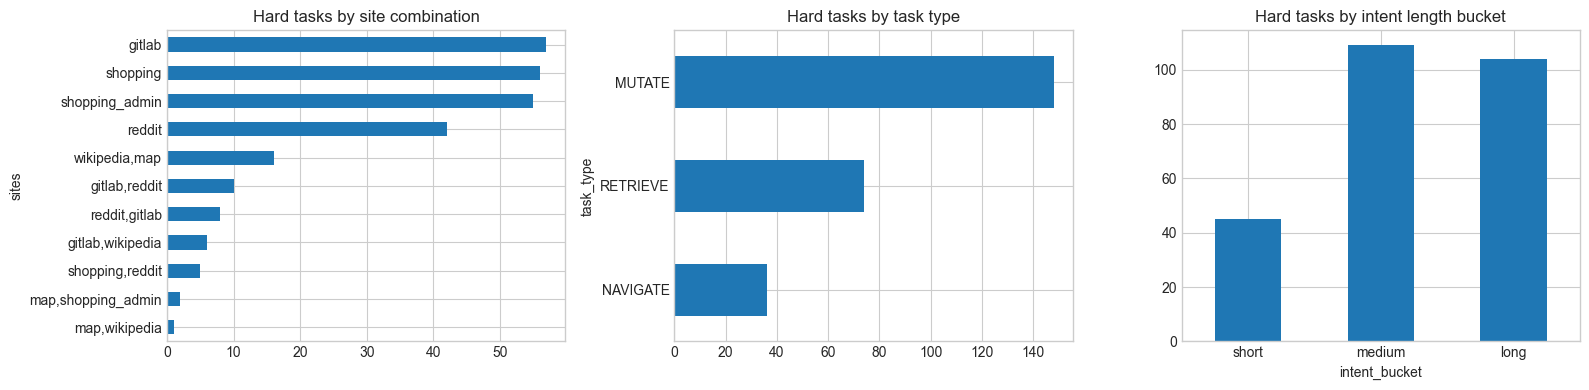

In [25]:
overview = pd.DataFrame([
    {'metric': 'all_tasks', 'value': len(all_df)},
    {'metric': 'hard_tasks', 'value': len(hard_df)},
    {'metric': 'hard_single_site', 'value': int(hard_df['single_site'].sum())},
    {'metric': 'hard_multi_site', 'value': int((~hard_df['single_site']).sum())},
    {'metric': 'hard_contains_map', 'value': int(hard_df['contains_map'].sum())},
    {'metric': 'hard_contains_wikipedia', 'value': int(hard_df['contains_wikipedia'].sum())},
])
display(overview)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
hard_df['sites'].value_counts().sort_values().plot(kind='barh', ax=axes[0], title='Hard tasks by site combination')
hard_df['task_type'].value_counts().sort_values().plot(kind='barh', ax=axes[1], title='Hard tasks by task type')
hard_df['intent_bucket'].value_counts().reindex(['short', 'medium', 'long']).plot(kind='bar', ax=axes[2], title='Hard tasks by intent length bucket', rot=0)
plt.tight_layout()


## Hard Subset Scope For Experiments

Offizielle Referenz laut WebArena-Verified Hard-Dokumentation: 258 Hard Tasks, davon 210 Single-site und 48 Multi-site. Single-site besteht nur aus Shopping Admin, GitLab, Reddit und Shopping; Single-site Map ist im Hard Subset wegen Kontaminationsproblemen ausgeschlossen.

Diese Zelle prueft die lokale Datei gegen diese Referenz und erzeugt die Tabellen, die fuer die Methodik-Auswahl relevant sind: Single-site-Verteilung, Task-Typen, Intent-Laengen und ein moeglicher Pool fuer fokussierte Experimente.

In [26]:
OFFICIAL_HARD_REFERENCE = pd.DataFrame([
    {'scope': 'Shopping Admin', 'single_site_tasks': 55, 'multi_site_tasks': 0, 'total_tasks': 55},
    {'scope': 'GitLab', 'single_site_tasks': 57, 'multi_site_tasks': 0, 'total_tasks': 57},
    {'scope': 'Reddit', 'single_site_tasks': 42, 'multi_site_tasks': 0, 'total_tasks': 42},
    {'scope': 'Shopping', 'single_site_tasks': 56, 'multi_site_tasks': 0, 'total_tasks': 56},
    {'scope': 'Multi-site', 'single_site_tasks': 0, 'multi_site_tasks': 48, 'total_tasks': 48},
    {'scope': 'Overall', 'single_site_tasks': 210, 'multi_site_tasks': 48, 'total_tasks': 258},
])

SUPPORTED_SINGLE_SITES = ['gitlab', 'reddit', 'shopping', 'shopping_admin']
hard_single_site = hard_df[hard_df['single_site']].copy()
hard_single_supported = hard_single_site[hard_single_site['sites'].isin(SUPPORTED_SINGLE_SITES)].copy()
hard_multi_site = hard_df[~hard_df['single_site']].copy()

local_scope = pd.DataFrame([
    {'metric': 'hard_total', 'local_count': len(hard_df), 'official_reference': 258},
    {'metric': 'hard_single_site', 'local_count': len(hard_single_site), 'official_reference': 210},
    {'metric': 'hard_multi_site', 'local_count': len(hard_multi_site), 'official_reference': 48},
    {'metric': 'hard_single_supported_sites', 'local_count': len(hard_single_supported), 'official_reference': 210},
    {'metric': 'hard_single_map', 'local_count': int((hard_single_site['sites'] == 'map').sum()), 'official_reference': 0},
    {'metric': 'hard_single_wikipedia', 'local_count': int((hard_single_site['sites'] == 'wikipedia').sum()), 'official_reference': 0},
])
local_scope['matches_reference'] = local_scope['local_count'] == local_scope['official_reference']

display(OFFICIAL_HARD_REFERENCE)
display(local_scope)

assert len(hard_df) == 258
assert len(hard_single_site) == 210
assert len(hard_multi_site) == 48
assert set(hard_single_site['sites'].unique()) == set(SUPPORTED_SINGLE_SITES)


,scope,single_site_tasks,multi_site_tasks,total_tasks
0,Shopping Admin,55,0,55
1,GitLab,57,0,57
2,Reddit,42,0,42
3,Shopping,56,0,56
4,Multi-site,0,48,48
5,Overall,210,48,258


,metric,local_count,official_reference,matches_reference
0,hard_total,258,258,True
1,hard_single_site,210,210,True
2,hard_multi_site,48,48,True
3,hard_single_supported_sites,210,210,True
4,hard_single_map,0,0,True
5,hard_single_wikipedia,0,0,True


## Single-site Hard Distribution

Diese Tabellen sind die zentrale Begruendung fuer eine fokussierte Evaluation auf Single-site Tasks: Sie decken die vier relevanten Sites ab, vermeiden Multi-site/Map-Komplexitaet und zeigen, wie viel MUTATE-, NAVIGATE- und RETRIEVE-Anteil je Site vorhanden ist.

,site,tasks,share_of_single_site
0,gitlab,57,0.271429
1,reddit,42,0.200000
2,shopping,56,0.266667
3,shopping_admin,55,0.261905


task_type,MUTATE,NAVIGATE,RETRIEVE,All
sites,,,,
gitlab,36,6,15,57
reddit,36,0,6,42
shopping,21,10,25,56
shopping_admin,26,6,23,55
All,119,22,69,210


intent_bucket,short,medium,long,All
sites,,,,
gitlab,13,29,15,57
reddit,7,22,13,42
shopping,9,29,18,56
shopping_admin,16,24,15,55
All,45,104,61,210


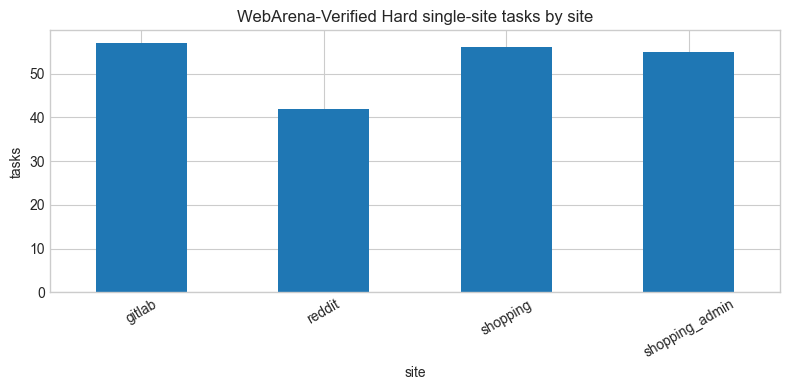

In [27]:
single_site_counts = (
    hard_single_supported['sites']
    .value_counts()
    .reindex(SUPPORTED_SINGLE_SITES)
    .rename_axis('site')
    .reset_index(name='tasks')
)
single_site_counts['share_of_single_site'] = single_site_counts['tasks'] / len(hard_single_supported)
display(single_site_counts)

single_site_type_counts = pd.crosstab(
    hard_single_supported['sites'],
    hard_single_supported['task_type'],
    margins=True,
).reindex(index=SUPPORTED_SINGLE_SITES + ['All'])
display(single_site_type_counts)

single_site_bucket_counts = pd.crosstab(
    hard_single_supported['sites'],
    hard_single_supported['intent_bucket'],
    margins=True,
).reindex(index=SUPPORTED_SINGLE_SITES + ['All'], columns=['short', 'medium', 'long', 'All'])
display(single_site_bucket_counts)

ax = single_site_counts.set_index('site')['tasks'].plot(
    kind='bar',
    figsize=(8, 4),
    title='WebArena-Verified Hard single-site tasks by site',
    rot=30,
)
ax.set_xlabel('site')
ax.set_ylabel('tasks')
plt.tight_layout()


## Focus Pool: Medium/Long And MUTATE Difficulty

Fuer eine kleine, aber aussagekraeftige Thesis-Evaluation kann man argumentieren: kurze Single-site Tasks dienen als Sanity-Check, waehrend medium/long Tasks und besonders MUTATE mehr Planungs- und Selbstpruefungsbedarf erzeugen. Die folgenden Tabellen zeigen transparent, wie gross dieser Pool ist und welche MUTATE-Last je Site entsteht.

In [28]:
hard_single_supported = hard_single_supported.assign(
    recommended_focus=hard_single_supported['intent_bucket'].isin(['medium', 'long']),
    is_mutate=hard_single_supported['task_type'].str.contains('MUTATE', na=False),
)

focus_summary = pd.DataFrame([
    {'pool': 'single_site_all', 'tasks': len(hard_single_supported)},
    {'pool': 'single_site_short', 'tasks': int((hard_single_supported['intent_bucket'] == 'short').sum())},
    {'pool': 'single_site_medium_long', 'tasks': int(hard_single_supported['recommended_focus'].sum())},
    {'pool': 'single_site_mutate', 'tasks': int(hard_single_supported['is_mutate'].sum())},
    {'pool': 'single_site_medium_long_mutate', 'tasks': int((hard_single_supported['recommended_focus'] & hard_single_supported['is_mutate']).sum())},
])
display(focus_summary)

focus_by_site = pd.crosstab(
    hard_single_supported['sites'],
    [hard_single_supported['intent_bucket'], hard_single_supported['task_type']],
).reindex(index=SUPPORTED_SINGLE_SITES)
display(focus_by_site)

mutate_pressure = (
    hard_single_supported
    .groupby('sites', dropna=False)
    .agg(
        tasks=('task_id', 'count'),
        mutate_tasks=('is_mutate', 'sum'),
        medium_long_tasks=('recommended_focus', 'sum'),
        medium_long_mutate_tasks=('task_id', lambda ids: int((hard_single_supported.loc[ids.index, 'recommended_focus'] & hard_single_supported.loc[ids.index, 'is_mutate']).sum())),
    )
    .reindex(SUPPORTED_SINGLE_SITES)
)
mutate_pressure['mutate_share'] = mutate_pressure['mutate_tasks'] / mutate_pressure['tasks']
display(mutate_pressure)


,pool,tasks
0,single_site_all,210
1,single_site_short,45
2,single_site_medium_long,165
3,single_site_mutate,119
4,single_site_medium_long_mutate,92


intent_bucket    long                   medium                    short  \
task_type      MUTATE NAVIGATE RETRIEVE MUTATE NAVIGATE RETRIEVE MUTATE   
sites                                                                     
gitlab             12        2        1     15        1       13      9   
reddit              8        0        5     21        0        1      7   
shopping            5        0       13     13        9        7      3   
shopping_admin      7        0        8     11        2       11      8   

intent_bucket                     
task_type      NAVIGATE RETRIEVE  
sites                             
gitlab                3        1  
reddit                0        0  
shopping              1        5  
shopping_admin        4        4

,tasks,mutate_tasks,medium_long_tasks,medium_long_mutate_tasks,mutate_share
sites,,,,,
gitlab,57,36,44,27,0.631579
reddit,42,36,35,29,0.857143
shopping,56,21,47,18,0.375000
shopping_admin,55,26,39,18,0.472727


## Candidate IDs For A Small Matrix Run

Die folgende Auswahl nimmt pro Site/Task-Typ/Laengenbucket bis zu zwei Tasks aus dem Single-site Hard Pool. Das ist keine finale Stichprobe, aber ein guter Startpunkt, wenn du 10-20 Tasks fuer eine volle H/K-Matrix testen willst.

In [29]:
candidate_matrix_pool = (
    hard_single_supported[hard_single_supported['recommended_focus']]
    .sort_values(['sites', 'task_type', 'intent_bucket', 'task_id'])
    .groupby(['sites', 'task_type', 'intent_bucket'], dropna=False)
    .head(2)
    .copy()
)

display(candidate_matrix_pool[['task_id', 'sites', 'task_type', 'intent_bucket', 'intent_length', 'gym_id', 'intent']])
print('Candidate task ids:')
print(' '.join(str(task_id) for task_id in candidate_matrix_pool['task_id'].tolist()))


,task_id,sites,task_type,intent_bucket,intent_length,gym_id,intent
415,415,gitlab,MUTATE,long,182,browsergym/webarena_verified.360.415.2,"Reply on the merge request assigned to me for verification functions: if the last comment is from the author, reply ""Thank you""; otherwise tag the author (e.g., @user) as a rem..."
416,416,gitlab,MUTATE,long,164,browsergym/webarena_verified.360.416.2,"Reply on the merge request assigned to me for wcag: if the last comment is from the author, reply ""Thank you""; otherwise tag the author (e.g., @user) as a reminder."
446,446,gitlab,MUTATE,medium,69,browsergym/webarena_verified.999.446.2,Assign the issue regarding 404 errors in a11yproject to Roshanjossey.
451,451,gitlab,MUTATE,medium,62,browsergym/webarena_verified.331.451.2,set the homepage URL on my GitLab profile to www.byteblaze.com
105,105,gitlab,NAVIGATE,long,161,browsergym/webarena_verified.349.105.2,Navigate to the page showing the list of not yet closed issues in the OpenAPITools/openapi-generator repository that have labels related to OpenAPI Generator CLI
106,106,gitlab,NAVIGATE,long,141,browsergym/webarena_verified.349.106.2,Navigate to the page showing the list of open issues in the umano/AndroidSlidingUpPanel repository that have labels related to all except BUG
343,343,gitlab,NAVIGATE,medium,86,browsergym/webarena_verified.299.343.2,Go to the list of all opened issues that don't have any labels for the current project
788,788,gitlab,RETRIEVE,long,229,browsergym/webarena_verified.316.788.4,"Get the full name, username, user location and email of the contributor who has the most commits to branch php52 in the current repository. Return a list of objects with keys ""..."
170,170,gitlab,RETRIEVE,medium,77,browsergym/webarena_verified.289.170.2,Get the project ID(s) of my personal project(s) that received the least stars
171,171,gitlab,RETRIEVE,medium,79,browsergym/webarena_verified.289.171.2,Get the project ID(s) of my personal project(s) that received less than 5 stars


Candidate task ids:
415 416 446 451 105 106 343 788 170 171 580 581 400 401 28 29 66 507 509 431 432 240 271 50 96 21 25 544 545 488 489 707 708 108 110 11 15


## Observed Step Budget From Existing Runs

Die WebArena-Verified-Datasetdatei enthaelt keine optimale Schrittzahl pro Task. Fuer die Budgetwahl kann man aber die bereits erzeugten Agent-Run-Summaries auswerten. Die folgenden Werte sind deshalb **beobachtete Agent-Schritte unter dem jeweiligen Budget**, nicht Ground-Truth-Minimalschritte. Sie helfen dabei, `--max-steps` und `--max-planner-calls` plausibel zu setzen.


step_summary_paths:
- /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-random-gemma4-v2-planact-main-00-22/summary.csv


,eda_subset,rows,tasks,mean_steps,median_steps,p90_steps,max_observed_steps,mean_max_steps,success_rate
1,hard_single_supported+current_v2_planact_experiment,63,3,17.4,15.0,27.6,30,30.0,0.0%
2,hard_single_supported+smoke_candidates+current_v2_planact_experiment,50,2,1.0,1.0,1.0,1,30.0,100.0%
0,hard_single_supported+candidate_matrix_pool+smoke_candidates+current_v2_planact_experiment,25,1,3.0,1.0,6.8,13,30.0,80.0%


,site,sites,task_type,h,k,rows,tasks,mean_steps,p90_steps,max_observed_steps,success_rate
0,gitlab,gitlab,MUTATE,0,0,3,3,4.0,4.0,4,0.0%
1,gitlab,gitlab,MUTATE,0,1,3,3,6.0,6.0,6,0.0%
2,gitlab,gitlab,MUTATE,0,2,3,3,26.0,26.0,26,0.0%
3,gitlab,gitlab,MUTATE,0,5,3,3,30.0,30.0,30,0.0%
4,gitlab,gitlab,MUTATE,0,10,3,3,26.0,26.0,26,0.0%
5,gitlab,gitlab,MUTATE,1,0,3,3,15.0,15.0,15,0.0%
6,gitlab,gitlab,MUTATE,1,1,3,3,15.0,15.0,15,0.0%
7,gitlab,gitlab,MUTATE,1,2,3,3,nan,nan,nan,0.0%
8,gitlab,gitlab,MUTATE,1,5,3,3,nan,nan,nan,0.0%
9,gitlab,gitlab,MUTATE,1,10,3,3,nan,nan,nan,0.0%


**Planner-Call-Budget-Heuristik:** `ceil(max_steps / h) + 2` fuer Horizon-Replans plus Runtime-Replan-Puffer.

,h,max_steps_reference,min_calls_for_horizon,recommended_with_margin
0,1,30,30,32
1,2,30,15,17
2,5,30,6,8
3,10,30,3,5


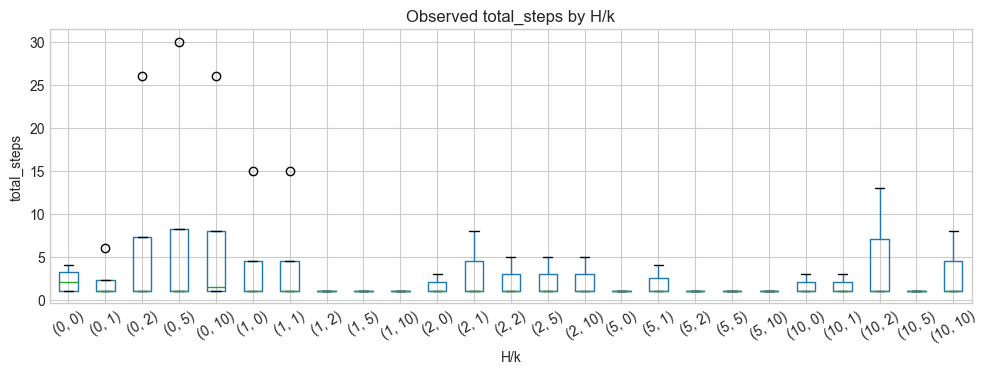

In [30]:
from pathlib import Path
import math
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

RUNS_ROOT = ROOT / 'runs/hk-agent'
PREFERRED_STEP_SUMMARY = RUNS_ROOT / 'hk-agent-browsergym-random-gemma4-v2-planact-main-00-22' / 'summary.csv'

if PREFERRED_STEP_SUMMARY.exists():
    step_summary_paths = [PREFERRED_STEP_SUMMARY]
else:
    step_summary_paths = sorted(RUNS_ROOT.glob('*/summary.csv'))

print('step_summary_paths:')
for path in step_summary_paths[:10]:
    print('-', path)
if len(step_summary_paths) > 10:
    print('...')

if not step_summary_paths:
    print('Noch keine run summaries gefunden. Erst einen Agent-Lauf ausfuehren, dann diese Zelle erneut starten.')
else:
    observed_runs = []
    for path in step_summary_paths:
        frame = pd.read_csv(path)
        frame['summary_path'] = str(path)
        observed_runs.append(frame)
    observed = pd.concat(observed_runs, ignore_index=True)

    required_cols = {'task_id', 'total_steps'}
    missing = required_cols - set(observed.columns)
    if missing:
        raise KeyError(f'In summary.csv fehlen Spalten: {sorted(missing)}')

    observed['task_id'] = observed['task_id'].astype(int)
    observed['total_steps'] = pd.to_numeric(observed['total_steps'], errors='coerce')
    observed['max_steps'] = pd.to_numeric(observed.get('max_steps', pd.Series(index=observed.index)), errors='coerce')
    observed['h'] = pd.to_numeric(observed.get('h', pd.Series(index=observed.index)), errors='coerce')
    observed['k'] = pd.to_numeric(observed.get('k', pd.Series(index=observed.index)), errors='coerce')
    observed['official_success_bool'] = observed.get('official_success', False).fillna(False).astype(str).str.lower().isin({'true', '1', 'yes'})

    # Subsets from this EDA notebook.
    supported_hard_ids = set(hard_single_supported['task_id'].astype(int)) if 'hard_single_supported' in globals() else set()
    matrix_ids = set(candidate_matrix_pool['task_id'].astype(int)) if 'candidate_matrix_pool' in globals() else set()
    smoke_ids = set(candidate_ids) if 'candidate_ids' in globals() else set()
    current_experiment_ids = set([44, 157, 105, 522, 800, 444, 407, 644, 28, 387, 795, 507, 505, 15, 108])

    def subset_label(task_id):
        labels = []
        if task_id in supported_hard_ids:
            labels.append('hard_single_supported')
        if task_id in matrix_ids:
            labels.append('candidate_matrix_pool')
        if task_id in smoke_ids:
            labels.append('smoke_candidates')
        if task_id in current_experiment_ids:
            labels.append('current_v2_planact_experiment')
        return '+'.join(labels) if labels else 'other_observed'

    observed['eda_subset'] = observed['task_id'].map(subset_label)
    observed_focus = observed[observed['eda_subset'].ne('other_observed')].copy()
    if observed_focus.empty:
        observed_focus = observed.copy()
        observed_focus['eda_subset'] = 'all_observed_runs'

    if 'capability_tier' not in observed_focus.columns or observed_focus['capability_tier'].isna().all():
        tier_lookup = all_df[['task_id', 'capability_tier']].drop_duplicates()
        observed_focus = observed_focus.drop(columns=['capability_tier'], errors='ignore').merge(tier_lookup, on='task_id', how='left')

    step_overview = observed_focus.groupby('eda_subset', dropna=False).agg(
        rows=('task_id', 'count'),
        tasks=('task_id', 'nunique'),
        mean_steps=('total_steps', 'mean'),
        median_steps=('total_steps', 'median'),
        p90_steps=('total_steps', lambda x: x.quantile(0.90)),
        max_observed_steps=('total_steps', 'max'),
        mean_max_steps=('max_steps', 'mean'),
        success_rate=('official_success_bool', 'mean'),
    ).reset_index().sort_values('rows', ascending=False)
    display(step_overview.style.format({
        'mean_steps': '{:.1f}',
        'median_steps': '{:.1f}',
        'p90_steps': '{:.1f}',
        'max_observed_steps': '{:.0f}',
        'mean_max_steps': '{:.1f}',
        'success_rate': '{:.1%}',
    }))

    observed_budget_by_tier = observed_focus.groupby('capability_tier', dropna=False).agg(
        rows=('task_id', 'count'),
        tasks=('task_id', 'nunique'),
        mean_steps=('total_steps', 'mean'),
        median_steps=('total_steps', 'median'),
        p90_steps=('total_steps', lambda x: x.quantile(0.90)),
        max_observed_steps=('total_steps', 'max'),
        success_rate=('official_success_bool', 'mean'),
    ).reset_index()
    proposed_budget = pd.DataFrame([
        {'capability_tier': 'navigation', 'proposed_max_steps': 10, 'reason': 'Route-finding should usually finish quickly; p90 is checked against observed runs.'},
        {'capability_tier': 'visible_retrieve', 'proposed_max_steps': 20, 'reason': 'Retrieval often needs search/open/read/finalize steps.'},
        {'capability_tier': 'structured_retrieve', 'proposed_max_steps': 20, 'reason': 'Aggregates/reviews need filtering and evidence checking.'},
        {'capability_tier': 'policy', 'proposed_max_steps': 15, 'reason': 'Policy/account tasks need inspection, but should stop once action is visibly unavailable.'},
        {'capability_tier': 'mutation', 'proposed_max_steps': 30, 'reason': 'State-changing tasks need navigation, form interaction, submission, and confirmation.'},
    ])
    budget_rationale = proposed_budget.merge(observed_budget_by_tier, on='capability_tier', how='left')
    budget_rationale['budget_minus_p90'] = budget_rationale['proposed_max_steps'] - budget_rationale['p90_steps']
    display(Markdown('**Proposed tiered `max_steps` policy, grounded in observed Agent steps**'))
    display(budget_rationale.style.format({
        'mean_steps': '{:.1f}',
        'median_steps': '{:.1f}',
        'p90_steps': '{:.1f}',
        'max_observed_steps': '{:.0f}',
        'success_rate': '{:.1%}',
        'budget_minus_p90': '{:.1f}',
    }).background_gradient(subset=['proposed_max_steps'], cmap='Blues'))

    group_cols = [col for col in ['site', 'sites', 'task_type', 'capability_tier', 'h', 'k'] if col in observed_focus.columns]
    if group_cols:
        step_by_group = observed_focus.groupby(group_cols, dropna=False).agg(
            rows=('task_id', 'count'),
            tasks=('task_id', 'nunique'),
            mean_steps=('total_steps', 'mean'),
            p90_steps=('total_steps', lambda x: x.quantile(0.90)),
            max_observed_steps=('total_steps', 'max'),
            success_rate=('official_success_bool', 'mean'),
        ).reset_index().sort_values(group_cols)
        display(step_by_group.style.format({
            'mean_steps': '{:.1f}',
            'p90_steps': '{:.1f}',
            'max_observed_steps': '{:.0f}',
            'success_rate': '{:.1%}',
        }))

    horizons = [1, 2, 5, 10]
    max_steps_candidates = sorted(int(x) for x in observed_focus['max_steps'].dropna().unique()) or [15, 20]
    max_steps_reference = max(max_steps_candidates)
    planner_budget = pd.DataFrame([
        {
            'h': h,
            'max_steps_reference': max_steps_reference,
            'min_calls_for_horizon': math.ceil(max_steps_reference / h),
            'recommended_with_margin': math.ceil(max_steps_reference / h) + 2,
        }
        for h in horizons
    ])
    display(Markdown('**Planner-Call-Budget-Heuristik:** `ceil(max_steps / h) + 2` fuer Horizon-Replans plus Runtime-Replan-Puffer.'))
    display(planner_budget)

    if {'site', 'h', 'k'}.issubset(observed_focus.columns):
        plot_df = observed_focus.dropna(subset=['total_steps']).copy()
        ax = plot_df.boxplot(column='total_steps', by=['h', 'k'], figsize=(10, 4), rot=30)
        ax.set_title('Observed total_steps by H/k')
        ax.set_xlabel('H/k')
        ax.set_ylabel('total_steps')
        plt.suptitle('')
        plt.tight_layout()
        plt.show()


## Frequencies By Category

In [31]:
site_type_summary = hard_df.groupby(['sites', 'task_type'], dropna=False).agg(
    tasks=('task_id', 'count'),
    mean_intent_length=('intent_length', 'mean'),
    mean_word_count=('intent_word_count', 'mean'),
    example_task_id=('task_id', 'first'),
    example_intent=('intent', 'first'),
).sort_values(['sites', 'task_type'])
display(site_type_summary)

bucket_summary = hard_df.groupby(['sites', 'task_type', 'intent_bucket'], dropna=False).agg(
    tasks=('task_id', 'count'),
    mean_intent_length=('intent_length', 'mean'),
    example_task_id=('task_id', 'first'),
    example_intent=('intent', 'first'),
).sort_values(['sites', 'task_type', 'intent_bucket'])
display(bucket_summary)


tasks  mean_intent_length  mean_word_count  \
sites              task_type                                               
gitlab             MUTATE        36          112.583333        18.694444   
                   NAVIGATE       6           81.500000        13.833333   
                   RETRIEVE      15           97.000000        16.800000   
gitlab,reddit      MUTATE        10          386.600000        70.400000   
gitlab,wikipedia   MUTATE         6          368.333333        60.333333   
map,shopping_admin NAVIGATE       2          155.000000        27.500000   
map,wikipedia      RETRIEVE       1          352.000000        57.000000   
reddit             MUTATE        36          105.944444        18.722222   
                   RETRIEVE       6          220.166667        38.833333   
reddit,gitlab      MUTATE         8          173.000000        28.250000   
shopping           MUTATE        21          125.761905        22.190476   
                   NAVIGATE      10           82.500000        14.500000   
                   RETRIEVE      25          134.280000        23.640000   
shopping,reddit    MUTATE         5          360.200000        62.200000   
shopping_admin     MUTATE        26          105.961538        18.846154   
                   NAVIGATE       6           52.000000        10.333333   
                   RETRIEVE      23          116.913043        20.478261   
wikipedia,map      NAVIGATE      12          220.750000        39.250000   
                   RETRIEVE       4          435.000000        72.750000   

                              example_task_id  \
sites              task_type                    
gitlab             MUTATE                 397   
                   NAVIGATE                44   
                   RETRIEVE               170   
gitlab,reddit      MUTATE                 552   
gitlab,wikipedia   MUTATE                 556   
map,shopping_admin NAVIGATE               759   
map,wikipedia      RETRIEVE                97   
reddit             MUTATE                 399   
                   RETRIEVE                28   
reddit,gitlab      MUTATE                 681   
shopping           MUTATE                 431   
                   NAVIGATE               240   
                   RETRIEVE                21   
shopping,reddit    MUTATE                 671   
shopping_admin     MUTATE                 488   
                   NAVIGATE               157   
                   RETRIEVE                11   
wikipedia,map      NAVIGATE               424   
                   RETRIEVE               265   

                                                                                                                                                                                                   example_intent  
sites              task_type                                                                                                                                                                                       
gitlab             MUTATE                                                                                                                                                                           Fork MetaSeq.  
                   NAVIGATE                                                                                                                                                                    Open my todos page  
                   RETRIEVE                                                                                                         Get the project ID(s) of my personal project(s) that received the least stars  
gitlab,reddit      MUTATE     Use the Web IDE to create a folder named real_space in gimmiethat.space repo. Within it, create a file named urls.json that contains the full URLs of the 5 most recent posts fr...  
gitlab,wikipedia   MUTATE     Create a repository named nolan_honest_fans with a README file containing only Christopher Nolan's th

tasks  mean_intent_length  \
sites              task_type intent_bucket                              
gitlab             MUTATE    long              12          183.833333   
                             medium            15           99.600000   
                             short              9           39.222222   
                   NAVIGATE  long               2          151.000000   
                             medium             1           86.000000   
                             short              3           33.666667   
                   RETRIEVE  long               1          229.000000   
                             medium            13           92.461538   
                             short              1           24.000000   
gitlab,reddit      MUTATE    long              10          386.600000   
gitlab,wikipedia   MUTATE    long               6          368.333333   
map,shopping_admin NAVIGATE  long               2          155.000000   
map,wikipedia      RETRIEVE  long               1          352.000000   
reddit             MUTATE    long               8          168.500000   
                             medium            21          100.142857   
                             short              7           51.857143   
                   RETRIEVE  long               5          241.000000   
                             medium             1          116.000000   
reddit,gitlab      MUTATE    long               3          256.666667   
                             medium             5          122.800000   
shopping           MUTATE    long               5          213.000000   
                             medium            13          110.153846   
                             short              3           48.000000   
                   NAVIGATE  medium             9           85.222222   
                             short              1           58.000000   
                   RETRIEVE  long              13          188.615385   
                             medium             7           91.000000   
                             short              5           53.600000   
shopping,reddit    MUTATE    long               5          360.200000   
shopping_admin     MUTATE    long               7          184.000000   
                             medium            11           98.545455   
                             short              8           47.875000   
                   NAVIGATE  medium             2           68.000000   
                             short              4           44.000000   
                   RETRIEVE  long               8          179.000000   
                             medium            11           96.181818   
                             short              4           49.750000   
wikipedia,map      NAVIGATE  long              12          220.750000   
                   RETRIEVE  long               4          435.000000   

                                            example_task_id  \
sites              task_type intent_bucket                    
gitlab             MUTATE    long                       415   
                             medium                     446   
                             short                      397   
                   NAVIGATE  long                       105   
                             medium                     343   
                             short                       44   
                   RETRIEVE  long                       788   
                             medium                     170   
                             short                      259   
gitlab,reddit      MUTATE    long                       552   
gitlab,wikipedia   MUTATE    long                       556   
map,shopping_admin NAVIGATE  long                       759   
map,wikipedia      RETRIEVE  long                        97   
reddit             MUTATE    long                       580   
                             medium       

## Evaluator Distribution

,evaluator_names,tasks
0,AgentResponseEvaluator+NetworkEventEvaluator,140
1,AgentResponseEvaluator,71
2,AgentResponseEvaluator+NetworkEventEvaluator+NetworkEventEvaluator,33
3,AgentResponseEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator,4
4,AgentResponseEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator,4
5,AgentResponseEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator,3
6,AgentResponseEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator...,2
7,AgentResponseEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator...,1


evaluator_names,AgentResponseEvaluator,AgentResponseEvaluator+NetworkEventEvaluator,AgentResponseEvaluator+NetworkEventEvaluator+NetworkEventEvaluator,AgentResponseEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator,AgentResponseEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator,AgentResponseEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator,AgentResponseEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator,AgentResponseEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator+NetworkEventEvaluator
sites,,,,,,,,
gitlab,16,26,11,1,1,2,0,0
"gitlab,reddit",0,5,5,0,0,0,0,0
"gitlab,wikipedia",0,0,6,0,0,0,0,0
"map,shopping_admin",0,2,0,0,0,0,0,0
"map,wikipedia",0,1,0,0,0,0,0,0
reddit,6,31,2,0,0,0,1,2
"reddit,gitlab",0,8,0,0,0,0,0,0
shopping,25,25,3,0,3,0,0,0
"shopping,reddit",0,5,0,0,0,0,0,0


Text(0.5, 0, 'tasks')

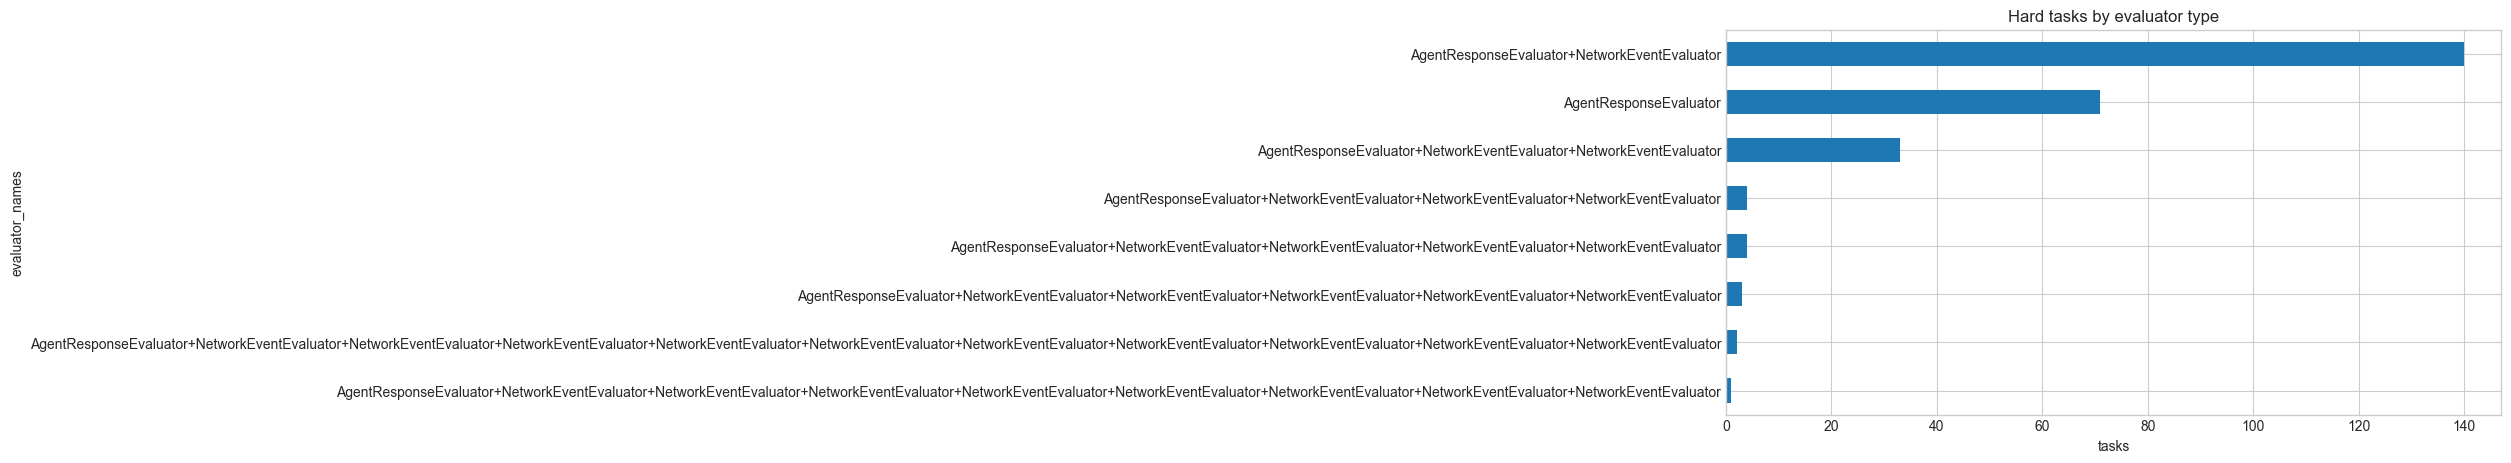

In [32]:
evaluator_counts = hard_df['evaluator_names'].value_counts().rename_axis('evaluator_names').reset_index(name='tasks')
display(evaluator_counts)

evaluator_by_site = pd.crosstab(hard_df['sites'], hard_df['evaluator_names'])
display(evaluator_by_site)

ax = evaluator_counts.set_index('evaluator_names')['tasks'].sort_values().plot(kind='barh', figsize=(10, 5), title='Hard tasks by evaluator type')
ax.set_xlabel('tasks')


## Intent Length Distribution

,intent_length,intent_word_count
count,258.000000,258.000000
mean,147.375969,25.647287
std,100.828408,17.379144
min,13.000000,2.000000
25%,74.500000,13.000000
50%,119.000000,20.000000
75%,182.750000,31.000000
max,460.000000,80.000000


,task_id,sites,task_type,intent_length,gym_id,intent
266,266,"wikipedia,map",RETRIEVE,460,browsergym/webarena_verified.85.266.4,"Get the relation ID of the closest national park to the largest city in Maine and the distance to drive there. Return a list of objects with keys ""relation_id"" (integer) and ""d..."
265,265,"wikipedia,map",RETRIEVE,441,browsergym/webarena_verified.85.265.4,"Get the relation ID of the closest national park to Boston and the distance to drive there. Return a list of objects with keys ""relation_id"" (integer) and ""distance"" (numeric v..."
562,562,"gitlab,reddit",MUTATE,437,browsergym/webarena_verified.88.562.2,Create a private repository named Awesome_DIY_ideas with a README file containing links to the 6 most active DIY posts from the DIY forum. Use the Web IDE to create the README....
563,563,"gitlab,reddit",MUTATE,435,browsergym/webarena_verified.88.563.2,Create a private repository named fun_thing_to_do with a README file containing links to the 5 most active DIY posts from the DIY forum. Use the Web IDE to create the README. S...
566,566,"gitlab,reddit",MUTATE,432,browsergym/webarena_verified.88.566.2,Create a private repository named Do it myself with a README file containing links to the 8 most active DIY posts from the DIY forum. Use the Web IDE to create the README. Stru...
564,564,"gitlab,reddit",MUTATE,431,browsergym/webarena_verified.88.564.2,Create a private repository named live_a_life with a README file containing links to the 3 most active DIY posts from the DIY forum. Use the Web IDE to create the README. Struc...
267,267,"wikipedia,map",RETRIEVE,427,browsergym/webarena_verified.85.267.4,"Get the relation ID of the closest national park to the hometown of Stephen King and the time to drive there. Return a list of objects with keys ""relation_id"" (integer) and ""du..."
565,565,"gitlab,reddit",MUTATE,425,browsergym/webarena_verified.88.565.2,Create a private repository named TODO with a README file containing links to the 10 most active DIY posts from the DIY forum. Use the Web IDE to create the README. Structure i...
268,268,"wikipedia,map",RETRIEVE,412,browsergym/webarena_verified.85.268.4,"Get the relation ID of the closest national park to Vinalhaven, ME and the time to bike there. Return a list of objects with keys ""relation_id"" (integer) and ""duration"" (in HH:..."
674,674,"shopping,reddit",MUTATE,389,browsergym/webarena_verified.101.674.2,Create a post in the game related discussion forum about Doc and Pies Arcade Factory Cocktail Arcade Machine to report customer reviews with 3 stars and less rating from the On...


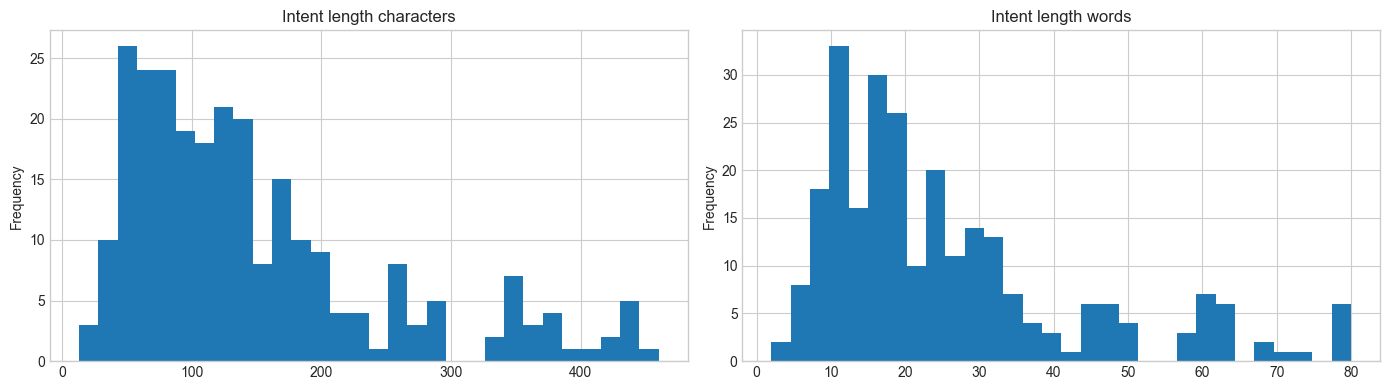

In [33]:
display(hard_df[['intent_length', 'intent_word_count']].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hard_df['intent_length'].plot(kind='hist', bins=30, ax=axes[0], title='Intent length characters')
hard_df['intent_word_count'].plot(kind='hist', bins=30, ax=axes[1], title='Intent length words')
plt.tight_layout()

longest = hard_df.sort_values('intent_length', ascending=False).head(10)
display(longest[['task_id', 'sites', 'task_type', 'intent_length', 'gym_id', 'intent']])


## Example Rows Per Category

In [34]:
examples_per_site_type = hard_df.sort_values(['sites', 'task_type', 'task_id']).groupby(['sites', 'task_type'], dropna=False).head(3)
display(examples_per_site_type[['task_id', 'sites', 'task_type', 'intent_bucket', 'intent_template_id', 'revision', 'gym_id', 'intent']])

examples_per_bucket = hard_df.sort_values(['intent_bucket', 'task_id']).groupby('intent_bucket', dropna=False).head(5)
display(examples_per_bucket[['task_id', 'sites', 'task_type', 'intent_bucket', 'intent_length', 'gym_id', 'intent']])


,task_id,sites,task_type,intent_bucket,intent_template_id,revision,gym_id,intent
397,397,gitlab,MUTATE,short,352,2,browsergym/webarena_verified.352.397.2,Fork MetaSeq.
398,398,gitlab,MUTATE,short,352,2,browsergym/webarena_verified.352.398.2,Fork all repos from Akilesh Kannan.
415,415,gitlab,MUTATE,long,360,2,browsergym/webarena_verified.360.415.2,"Reply on the merge request assigned to me for verification functions: if the last comment is from the author, reply ""Thank you""; otherwise tag the author (e.g., @user) as a rem..."
44,44,gitlab,NAVIGATE,short,303,2,browsergym/webarena_verified.303.44.2,Open my todos page
105,105,gitlab,NAVIGATE,long,349,2,browsergym/webarena_verified.349.105.2,Navigate to the page showing the list of not yet closed issues in the OpenAPITools/openapi-generator repository that have labels related to OpenAPI Generator CLI
106,106,gitlab,NAVIGATE,long,349,2,browsergym/webarena_verified.349.106.2,Navigate to the page showing the list of open issues in the umano/AndroidSlidingUpPanel repository that have labels related to all except BUG
170,170,gitlab,RETRIEVE,medium,289,2,browsergym/webarena_verified.289.170.2,Get the project ID(s) of my personal project(s) that received the least stars
171,171,gitlab,RETRIEVE,medium,289,2,browsergym/webarena_verified.289.171.2,Get the project ID(s) of my personal project(s) that received less than 5 stars
172,172,gitlab,RETRIEVE,medium,289,2,browsergym/webarena_verified.289.172.2,Get the project ID(s) of my personal project(s) that received no stars
552,552,"gitlab,reddit",MUTATE,long,84,2,browsergym/webarena_verified.84.552.2,"Use the Web IDE to create a folder named real_space in gimmiethat.space repo. Within it, create a file named urls.json that contains the full URLs of the 5 most recent posts fr..."


,task_id,sites,task_type,intent_bucket,intent_length,gym_id,intent
28,28,reddit,RETRIEVE,long,267,browsergym/webarena_verified.33.28.2,"In the Worcester forum, get the username and post title of the most recent post, and count the number of comments on that post that are not from the author and have more downvo..."
29,29,reddit,RETRIEVE,long,261,browsergym/webarena_verified.33.29.2,"In the DIY forum, get the username and post title of the most recent post, and count the number of comments on that post that are not from the author and have more downvotes th..."
31,31,reddit,RETRIEVE,long,274,browsergym/webarena_verified.33.31.2,"In the photoshopbattles forum, get the username and post title of the most recent post, and count the number of comments on that post that are not from the author and have more..."
50,50,shopping,RETRIEVE,long,287,browsergym/webarena_verified.197.50.2,"Today is June 12, 2023. Get how many complete orders I have over the past year, and the total amount of money I spent (including shipping and handling fees). Return an object w..."
67,67,reddit,RETRIEVE,long,165,browsergym/webarena_verified.17.67.2,"Among the top 10 hottest posts in the ""Books"" forum, get the book titles, exactly as they appear in the post description, from those that recommend exactly one book."
11,11,shopping_admin,RETRIEVE,medium,95,browsergym/webarena_verified.288.11.2,"Get the total number of reviews that our store received so far that mention term ""disappointed"""
15,15,shopping_admin,RETRIEVE,medium,87,browsergym/webarena_verified.288.15.2,"Get the total number of reviews that our store received so far that mention term ""best"""
21,21,shopping,RETRIEVE,medium,95,browsergym/webarena_verified.222.21.2,Get name(s) of reviewer(s) who mention ear cups being small for the product on the current page
25,25,shopping,RETRIEVE,medium,132,browsergym/webarena_verified.222.25.2,Get name(s) of reviewer(s) who mention print quality explicitly with a rating of 3 or less stars for the product on the current page
63,63,shopping_admin,RETRIEVE,medium,90,browsergym/webarena_verified.276.63.2,Get customer email(s) who completed the second most number of orders in the entire history


## Non-Hard Example Candidates

In [35]:
non_hard_df = all_df[~all_df['hard_subset']].copy()
non_hard_single_supported = non_hard_df[(non_hard_df['single_site']) & (~non_hard_df['contains_map']) & (~non_hard_df['contains_wikipedia'])].copy()

print('Non-hard tasks:', len(non_hard_df))
print('Non-hard single-site supported examples:', len(non_hard_single_supported))

non_hard_summary = non_hard_single_supported.groupby(['sites', 'task_type', 'intent_bucket'], dropna=False).agg(
    tasks=('task_id', 'count'),
    example_task_id=('task_id', 'first'),
    example_intent=('intent', 'first'),
).sort_values(['sites', 'task_type', 'intent_bucket'])
display(non_hard_summary)

non_hard_examples = non_hard_single_supported.sort_values(['sites', 'task_type', 'intent_bucket', 'task_id']).groupby(['sites', 'task_type'], dropna=False).head(5)
display(non_hard_examples[['task_id', 'sites', 'task_type', 'intent_bucket', 'intent_length', 'gym_id', 'intent']])


Non-hard tasks: 554
Non-hard single-site supported examples: 445


tasks  example_task_id  \
sites          task_type intent_bucket                           
gitlab         MUTATE    long              11              413   
                         medium            49              389   
                         short             15              394   
               NAVIGATE  medium             9               45   
                         short              1              258   
               RETRIEVE  long               2              317   
                         medium            36              132   
reddit         MUTATE    long              11              583   
                         medium            39              402   
                         short              9              404   
               RETRIEVE  long               3               27   
                         medium             1              726   
                         short              1              723   
shopping       MUTATE    long              13              469   
                         medium            19              433   
                         short              8              511   
               NAVIGATE  medium            25              118   
                         short             10              260   
               RETRIEVE  long              30               47   
                         medium            18               22   
                         short              8              231   
shopping_admin MUTATE    long               4              464   
                         medium            28              453   
                         short             20              423   
               NAVIGATE  medium             7              676   
                         short              5              374   
               RETRIEVE  long              12              107   
                         medium            35                2   
                         short             16                0   

                                                                                                                                                                                                             example_intent  
sites          task_type intent_bucket                                                                                                                                                                                       
gitlab         MUTATE    long                                              Change the LICENSE for repo byteblaze/a11y-syntax-highlighting to one that mandates all copies and derivative works to be under the same license  
                         medium                                                                                Post "Thanks, working on reviews" for the merge request related to octovisuals page in primer/design project  
                         short                                                                                                                                                                              Fork 2019-nCov.  
               NAVIGATE  medium                                                                                                        Open the issues page for the current project filtered to the most recent open issues  
                         short                                                                                                                                                             Open the public projects listing  
               RETRIEVE  long           Get the names and number of commits of the top 3 contributors (by commit count) to metaseq repo. Return a list of objects with keys "first_name", "last_name", and "number_of_co...  
                         medium                                                                                                                       How many commits did kilian make to a11yproject.com on March 5, 202

,task_id,sites,task_type,intent_bucket,intent_length,gym_id,intent
413,413,gitlab,MUTATE,long,144,browsergym/webarena_verified.355.413.2,Change the LICENSE for repo byteblaze/a11y-syntax-highlighting to one that mandates all copies and derivative works to be under the same license
442,442,gitlab,MUTATE,long,160,browsergym/webarena_verified.308.442.2,"Update and commit (to main) the website code for the current project using the simple online file editor to change the browser tab title to ""Welcome to my site"""
445,445,gitlab,MUTATE,long,147,browsergym/webarena_verified.308.445.2,"Update and commit (to main) the website code for the current project using the simple online file editor to change the browser tab title to ""Hello"""
593,593,gitlab,MUTATE,long,182,browsergym/webarena_verified.339.593.2,"Create a milestone in the current repo with title ""all branches to main"" for the upcoming task of merging all branches to main starting on March 15, 2044 and ending on March 30..."
594,594,gitlab,MUTATE,long,210,browsergym/webarena_verified.339.594.2,"Create a milestone in the current repo with title ""zsh comprehensive support"" for the upcoming task of adding a new branch for zsh comprehensive support starting on May 1, 2044..."
45,45,gitlab,NAVIGATE,medium,84,browsergym/webarena_verified.300.45.2,Open the issues page for the current project filtered to the most recent open issues
46,46,gitlab,NAVIGATE,medium,84,browsergym/webarena_verified.300.46.2,Open the issues page for the current project filtered to the most recent open issues
102,102,gitlab,NAVIGATE,medium,138,browsergym/webarena_verified.349.102.2,Navigate to the page showing the list of open issues in the a11yproject/a11yproject.com repository that have labels related to help wanted
103,103,gitlab,NAVIGATE,medium,133,browsergym/webarena_verified.349.103.2,Navigate to the page showing the list of closed issues in the kkroening/ffmpeg-python repository that have labels related to question
104,104,gitlab,NAVIGATE,medium,126,browsergym/webarena_verified.349.104.2,Navigate to the page showing the list of all issues in the keycloak/keycloak repository that have labels related to flaky-test


## Suggested Smoke Candidates

In [36]:
candidate_ids = [44, 157, 105, 27, 118]
candidate_df = all_df[all_df['task_id'].isin(candidate_ids)].copy()
candidate_df['analysis_role'] = candidate_df['task_id'].map({
    44: 'hard short gitlab navigate',
    157: 'hard medium shopping_admin navigate',
    105: 'hard long gitlab navigate',
    27: 'non-hard reddit retrieve example',
    118: 'non-hard shopping navigate example',
})
display(candidate_df[['task_id', 'analysis_role', 'hard_subset', 'sites', 'task_type', 'intent_bucket', 'intent_length', 'gym_id', 'intent']].sort_values('task_id'))


,task_id,analysis_role,hard_subset,sites,task_type,intent_bucket,intent_length,gym_id,intent
27,27,non-hard reddit retrieve example,False,reddit,RETRIEVE,long,275,browsergym/webarena_verified.33.27.2,"In the personal finances forum, get the username and post title of the most recent post, and count the number of comments on that post that are not from the author and have mor..."
44,44,hard short gitlab navigate,True,gitlab,NAVIGATE,short,18,browsergym/webarena_verified.303.44.2,Open my todos page
105,105,hard long gitlab navigate,True,gitlab,NAVIGATE,long,161,browsergym/webarena_verified.349.105.2,Navigate to the page showing the list of not yet closed issues in the OpenAPITools/openapi-generator repository that have labels related to OpenAPI Generator CLI
118,118,non-hard shopping navigate example,False,shopping,NAVIGATE,medium,100,browsergym/webarena_verified.151.118.2,"I have a jaw bruxism problem, go to the product page for something that could alleviate the problem."
157,157,hard medium shopping_admin navigate,True,shopping_admin,NAVIGATE,short,33,browsergym/webarena_verified.255.157.2,View the details of all customers
